In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 3. Feature Engineering

> **Context from EDA/Preprocessing:**  
> - Missing values filled via structural 0-fill (student vs professional split columns).  
> - Outliers retained.  
> - **Robust Scaler** chosen based on Levene's Test analysis.  
> - Perfect multicollinearity (r = ±1.0) between `Academic Pressure`/`Work Pressure` and `Study Satisfaction`/`Job Satisfaction`.  
> - `Sleep Duration` 36 dirty uniques, `Dietary Habits` 23, `Degree` 115.

> **Anti-leakage rule:** Every encoder map, category list, and scaler is **fit on train only** then applied to test mechanically.

## 0. Setup

In [24]:
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import RobustScaler

# ── Paths ─────────────────────────────────────────────────────────────
DATA_DIR     = Path("/content/drive/MyDrive/Data_for_IDA/data/processed")
ARTIFACT_DIR = Path("/content/drive/MyDrive/Data_for_IDA/artifacts")   # scalers / encoder maps saved here
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_IN  = DATA_DIR / "train.csv"
TEST_IN   = DATA_DIR / "valid.csv"
TRAIN_OUT = DATA_DIR / "fe_train.csv"
TEST_OUT  = DATA_DIR / "fe_valid.csv"

# ── Load ──────────────────────────────────────────────────────────────
train = pd.read_csv(TRAIN_IN)
test  = pd.read_csv(TEST_IN)

print("Train:", train.shape, "  Test:", test.shape)
train.head(3)

Train: (112552, 18)   Test: (28138, 18)


,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Female,52.0,Chennai,Working Professional,HR Manager,0.0,5.0,0.0,0.0,3.0,More than 8 hours,Unhealthy,ME,Yes,4.0,4.0,No,0
1,Female,45.0,Jaipur,Working Professional,Civil Engineer,0.0,4.0,0.0,0.0,4.0,More than 8 hours,Moderate,B.Tech,No,8.0,4.0,No,0
2,Male,38.0,Bangalore,Working Professional,Financial Analyst,0.0,3.0,0.0,0.0,2.0,5-6 hours,Moderate,B.Com,Yes,1.0,1.0,No,0


---
## 3.1 Step 1 - Text Normalization (Pre-Encoding Cleanup)

During EDA, we observed high cardinality and messy formatting in Sleep Duration (36 unique values), Dietary Habits (23), and Degree (115). Leaving these as-is would result in hundreds of meaningless one-hot encoded columns (the Curse of Dimensionality) and introduce noise. We use domain-based Regex mapping to group these into canonical categories. Because this is purely logic-based and doesn't rely on dataset statistics, it introduces no data leakage.

In [25]:
# 3.1a  Sleep Duration -> 4 canonical categories

def normalise_sleep(value):
    """Map free-text sleep duration to one of 4 canonical buckets."""
    if pd.isna(value):
        return "Other"
    v = str(value).strip().lower()
    if re.search(r"less|<\s*5|under\s*5|below\s*5", v):
        return "Less than 5h"
    if re.search(r"5[-\u20135\s]6|5 to 6", v):
        return "5-6h"
    if re.search(r"7[-\u20138\s]8|7 to 8", v):
        return "7-8h"
    if re.search(r"more|>\s*8|above\s*8|over\s*8|\b9\b|\b10\b|\b11\b|\b12\b", v):
        return "More than 8h"
    return "Other"

for df in [train, test]:
    df["Sleep Duration"] = df["Sleep Duration"].apply(normalise_sleep)

print("Sleep Duration — train value counts after normalisation:")
print(train["Sleep Duration"].value_counts())

Sleep Duration — train value counts after normalisation:
Sleep Duration
Less than 5h    31088
7-8h            29691
More than 8h    26105
5-6h            25613
Other              55
Name: count, dtype: int64


In [26]:
# 3.1b  Dietary Habits -> 3 canonical categories

def normalise_diet(value):
    if pd.isna(value):
        return "Moderate"
    v = str(value).strip().lower()
    if re.search(r"unhealthy|poor|bad|junk", v):
        return "Unhealthy"
    if re.search(r"health", v):  # catches healthy, very healthy, etc.
        return "Healthy"
    return "Moderate"  # absorbs typos and ambiguous entries

for df in [train, test]:
    df["Dietary Habits"] = df["Dietary Habits"].apply(normalise_diet)

print("Dietary Habits — train value counts after normalisation:")
print(train["Dietary Habits"].value_counts())

Dietary Habits — train value counts after normalisation:
Dietary Habits
Moderate     39720
Unhealthy    37068
Healthy      35764
Name: count, dtype: int64


In [27]:
# 3.1c  Degree -> 4 ordered education levels

def normalise_degree(value):
    if pd.isna(value):
        return "Bachelor"  # most-frequent safe default
    v = str(value).strip().lower()
    if re.search(r"phd|ph\.d|doctorate|doctoral", v):
        return "PhD"
    if re.search(
        r"^m\.|\.mtech|\bmba\b|\.msc|\bm\.a\b|\.mpharm|\.med|\.march|\bmaster",
        v):
        return "Master"
    if re.search(r"class 12|12th|hsc|high school|higher secondary|intermediate", v):
        return "High School"
    return "Bachelor"  # covers all B. prefixed degrees + unrecognised

for df in [train, test]:
    df["Degree"] = df["Degree"].apply(normalise_degree)

print("Degree — train value counts after normalisation:")
print(train["Degree"].value_counts())

Degree — train value counts after normalisation:
Degree
Bachelor       80912
Master         17288
High School    11870
PhD             2482
Name: count, dtype: int64


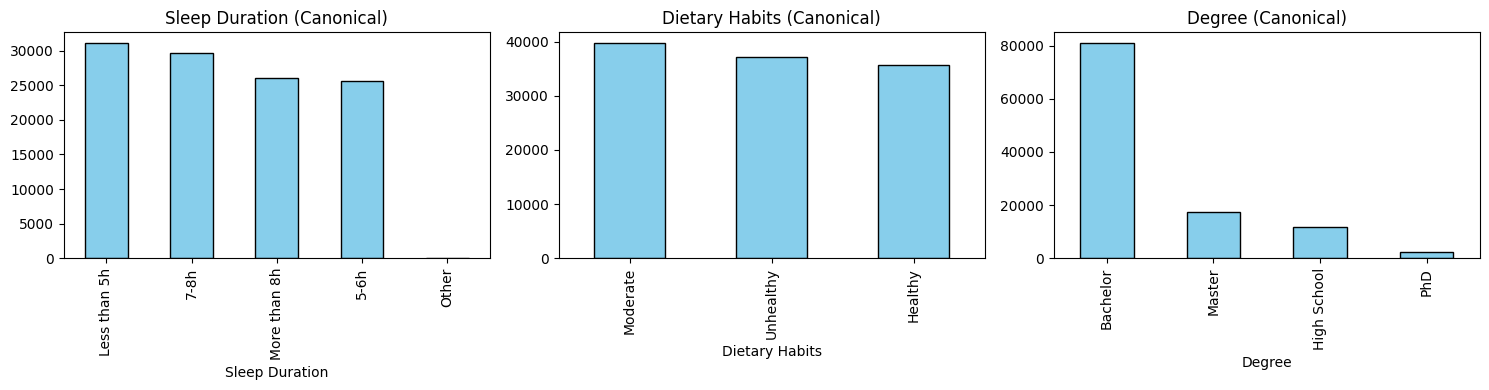

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
cols = ['Sleep Duration', 'Dietary Habits', 'Degree']
for i, col in enumerate(cols):
    train[col].value_counts().plot(kind='bar', ax=ax[i], color='skyblue', edgecolor='black')
    ax[i].set_title(f"{col} (Canonical)")
plt.tight_layout()
plt.show()

---
## 3.2 Step 2 — Feature Merging (Resolving Perfect Multicollinearity)

In the EDA phase, Pearson correlation analysis revealed perfect multicollinearity ($r = \pm1.0$) between Academic Pressure and Work Pressure, as well as Study Satisfaction and Job Satisfaction. This occurs because students and working professionals are mutually exclusive groups. To resolve this without losing information, we merge them into unified Pressure and Satisfaction variables and drop the original columns. This prevents unstable weights in linear models.

In [29]:
for df in [train, test]:
    df["Pressure"]     = df["Academic Pressure"] + df["Work Pressure"]
    df["Satisfaction"] = df["Study Satisfaction"] + df["Job Satisfaction"]
    df.drop(
        columns=["Academic Pressure", "Work Pressure",
                 "Study Satisfaction", "Job Satisfaction"],
        inplace=True)

# CGPA: keep — 0-fill already done in preprocessing.
# 0 acts as "not applicable" for professionals; tree models can exploit this.
# "Working Professional or Student" already captures group identity.

print("Columns after merge:")
print(train.columns.tolist())

Columns after merge:
['Gender', 'Age', 'City', 'Working Professional or Student', 'Profession', 'CGPA', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression', 'Pressure', 'Satisfaction']


---
## 3.3 Step 3 — Composite Features (Domain-Driven)

To help tree-based models capture non-linear interactions, we engineered two composite features based on domain logic:

1. Stress_Score: The sum of Pressure and Financial Stress, representing the total psychological burden.

2. Sleep_Risk_Flag: A binary indicator for sleeping less than 5 hours, a known clinical risk factor for depression.

In [30]:
for df in [train, test]:
    # Total psychological burden across two orthogonal stress dimensions
    df["Stress_Score"] = df["Pressure"] + df["Financial Stress"]

    # Clinical marker: sleep < 5h strongly linked to depression risk.
    # Applied AFTER normalise_sleep, so 'Less than 5h' is already canonical.
    df["Sleep_Risk_Flag"] = (df["Sleep Duration"] == "Less than 5h").astype(int)

print("Composite features preview:")
train[["Pressure", "Financial Stress", "Stress_Score",
       "Sleep Duration", "Sleep_Risk_Flag"]].head()

Composite features preview:


,Pressure,Financial Stress,Stress_Score,Sleep Duration,Sleep_Risk_Flag
0,5.0,4.0,9.0,More than 8h,0
1,4.0,4.0,8.0,More than 8h,0
2,3.0,1.0,4.0,5-6h,0
3,4.0,3.0,7.0,7-8h,0
4,2.0,3.0,5.0,Less than 5h,1


---
## 3.4 Step 4 — Encoding

All encoding maps and category lists are **derived from train only** then applied to test.

In [31]:
# 3.4a  Binary Encoding

BINARY_MAPS = {
    "Gender":                                {"Male": 1, "Female": 0},
    "Working Professional or Student":       {"Working Professional": 1, "Student": 0},
    "Have you ever had suicidal thoughts ?": {"Yes": 1, "No": 0},
    "Family History of Mental Illness":      {"Yes": 1, "No": 0},
}

RENAME_MAP = {
    "Have you ever had suicidal thoughts ?": "Suicidal_Thoughts",
    "Working Professional or Student":       "Is_Working_Professional",
}

for df in [train, test]:
    for col, mapping in BINARY_MAPS.items():
        df[col] = df[col].map(mapping)
    df.rename(columns=RENAME_MAP, inplace=True)

# Surface unexpected NaN introduced by values outside the binary map
for col in list(RENAME_MAP.values()) + ["Gender", "Family History of Mental Illness"]:
    n = train[col].isnull().sum()
    if n:
        print(f"WARNING: {n} NaN in {col} after binary encoding — check source values")

print("Binary encoding done. Sample:")
train[["Gender", "Is_Working_Professional",
       "Suicidal_Thoughts", "Family History of Mental Illness"]].head(3)

Binary encoding done. Sample:


,Gender,Is_Working_Professional,Suicidal_Thoughts,Family History of Mental Illness
0,0,1,1,0
1,0,1,0,0
2,1,1,1,0


In [32]:
# 3.4b  Ordinal Encoding
# Maps encode natural order — not derived from train statistics.
# "Other" in Sleep Duration falls back to 2 (median bucket).

ORDINAL_MAPS = {
    "Sleep Duration": {
        "Less than 5h": 1,
        "5-6h":         2,
        "7-8h":         3,
        "More than 8h": 4,
        "Other":        2,  # median fallback
    },
    "Dietary Habits": {
        "Unhealthy": 1,
        "Moderate":  2,
        "Healthy":   3,
    },
    "Degree": {
        "High School": 1,
        "Bachelor":    2,
        "Master":      3,
        "PhD":         4,
    },
}

joblib.dump(ORDINAL_MAPS, ARTIFACT_DIR / "ordinal_maps.pkl")

for df in [train, test]:
    for col, mapping in ORDINAL_MAPS.items():
        df[col] = df[col].map(mapping)

print("Ordinal columns after encoding:")
for col in ORDINAL_MAPS:
    print(f"  {col}: {sorted(train[col].dropna().unique())}")

Ordinal columns after encoding:
  Sleep Duration: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  Dietary Habits: [np.int64(1), np.int64(2), np.int64(3)]
  Degree: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


We apply One-Hot Encoding only to the most frequent categories to prevent feature explosion. `City` is limited to the top 15 and `Profession` to the top 10. All unseen or less frequent values in both Train and Test sets are grouped into an 'Other' bucket.

In [33]:
# 3.4c  High-Cardinality One-Hot Encoding
#   top-N lists computed on TRAIN only.
#   Test values outside that list are binned to "Other".
#   Test dummy columns reindexed to exactly match train (fill 0 for unseen).

def top_n_ohe(train_df, test_df, col, n, prefix):
    """Fit top-N on train, bin both splits, OHE, align columns, drop Other dummy."""
    top_cats = train_df[col].value_counts().nlargest(n).index.tolist()

    for df in [train_df, test_df]:
        df[col] = df[col].where(df[col].isin(top_cats), other="Other")

    train_d = pd.get_dummies(train_df[col], prefix=prefix, drop_first=False, dtype=int)
    test_d  = pd.get_dummies(test_df[col],  prefix=prefix, drop_first=False, dtype=int)
    test_d  = test_d.reindex(columns=train_d.columns, fill_value=0)

    # Drop "Other" dummy (reference category) to avoid the dummy variable trap
    for d in [train_d, test_d]:
        d.drop(columns=[f"{prefix}_Other"], inplace=True, errors="ignore")

    return (
        train_df.drop(columns=[col]).join(train_d),
        test_df.drop( columns=[col]).join(test_d),
        top_cats,
    )


train, test, city_top = top_n_ohe(train, test, "City",       n=15, prefix="City")
train, test, prof_top = top_n_ohe(train, test, "Profession", n=10, prefix="Prof")

joblib.dump({"city_top": city_top, "prof_top": prof_top},
            ARTIFACT_DIR / "ohe_categories.pkl")

# Coverage sanity check (re-read raw to avoid contamination)
raw = pd.read_csv(TRAIN_IN)
city_cov = raw["City"].isin(city_top).mean()
prof_cov = raw["Profession"].isin(prof_top).mean()
print(f"City  top-15 coverage in train : {city_cov:.1%}")
print(f"Prof  top-10 coverage in train : {prof_cov:.1%}")
print(f"Shape after OHE  -> Train: {train.shape}  Test: {test.shape}")

City  top-15 coverage in train : 56.9%
Prof  top-10 coverage in train : 65.6%
Shape after OHE  -> Train: (112552, 41)  Test: (28138, 41)


---
## 3.5 Step 5 — Scaling

**Robust Scaler** selected from Levene's Test analysis (EDA Section 2.4).  
Based on the Levene's Test from EDA showing significant variance heterogeneity, we apply RobustScaler to continuous features. Unlike `StandardScaler`, `RobustScaler` uses the median and IQR, making it resistant to the outliers we chose to retain in the previous step. We fit the scaler strictly on the Training set to prevent data leakage.

In [34]:
SCALE_COLS = [
    "Age",
    "CGPA",
    "Work/Study Hours",
    "Financial Stress",
    "Pressure",
    "Satisfaction",
    "Stress_Score",
]

missing_cols = [c for c in SCALE_COLS if c not in train.columns]
assert not missing_cols, f"Missing scale columns: {missing_cols}"

# Fit on TRAIN only
scaler = RobustScaler()
train[SCALE_COLS] = scaler.fit_transform(train[SCALE_COLS])

# Apply to TEST (transform only — never re-fit)
test[SCALE_COLS]  = scaler.transform(test[SCALE_COLS])

# Persist scaler + column list for model notebook and inference pipeline
joblib.dump({"scaler": scaler, "scale_cols": SCALE_COLS},
            ARTIFACT_DIR / "robust_scaler.pkl")

print("Scaler saved to", ARTIFACT_DIR / "robust_scaler.pkl")
print("\nScaled column stats (train — should be centered near 0):")
train[SCALE_COLS].describe().round(3)

Scaler saved to /content/drive/MyDrive/Data_for_IDA/artifacts/robust_scaler.pkl

Scaled column stats (train — should be centered near 0):


,Age,CGPA,Work/Study Hours,Financial Stress,Pressure,Satisfaction,Stress_Score
count,112552.000,112552.000,112552.000,112552.000,112552.000,112552.000,112552.000
mean,-0.074,1.520,0.035,-0.006,0.013,-0.016,0.008
std,0.563,3.122,0.551,0.707,0.701,0.703,1.021
min,-1.091,0.000,-0.857,-1.000,-1.500,-1.500,-2.500
25%,-0.591,0.000,-0.429,-0.500,-0.500,-0.500,-0.500
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.409,0.000,0.571,0.500,0.500,0.500,0.500
max,0.818,10.000,0.857,1.000,1.000,2.000,2.000


---
## 3.6 Step 6 — Post-Encoding Check
Observation from Correlation Plot: The newly engineered `Stress_Score` and unified `Pressure` variables show strong positive correlations with `Depression`, validating our feature merging strategy. Conversely, `Age` and `Is_Working_Professional` show strong negative correlations, suggesting that younger individuals (students) in this dataset are at higher risk.

In [35]:
print("── Shape ──────────────────────────────────────────")
print(f"  Train : {train.shape}")
print(f"  Test  : {test.shape}")
assert train.shape[1] == test.shape[1], "Column count mismatch between train and test!"
assert list(train.columns) == list(test.columns), "Column order mismatch!"

print("\n── Missing values (train) ─────────────────────────")
nulls = train.isnull().sum()
print(nulls[nulls > 0].to_string() if nulls.any() else "  None — clean.")

print("\n── Missing values (test) ──────────────────────────")
nulls_t = test.isnull().sum()
print(nulls_t[nulls_t > 0].to_string() if nulls_t.any() else "  None — clean.")

print("\n── Near-zero-variance binary columns (<0.5% or >99.5% positive rate) ──")
bin_cols = [c for c in train.columns
            if set(train[c].dropna().unique()).issubset({0, 1})]
low_var  = [(c, f"{train[c].mean():.3%}") for c in bin_cols
            if train[c].mean() < 0.005 or train[c].mean() > 0.995]
print(low_var if low_var else "  None found.")

print("\n── dtypes ─────────────────────────────────────────")
print(train.dtypes.value_counts())

── Shape ──────────────────────────────────────────
  Train : (112552, 41)
  Test  : (28138, 41)

── Missing values (train) ─────────────────────────
  None — clean.

── Missing values (test) ──────────────────────────
  None — clean.

── Near-zero-variance binary columns (<0.5% or >99.5% positive rate) ──
  None found.

── dtypes ─────────────────────────────────────────
int64      34
float64     7
Name: count, dtype: int64


In [36]:
print("Final column inventory:")
for i, c in enumerate(train.columns, 1):
    print(f"  {i:3d}. {c}")

Final column inventory:
    1. Gender
    2. Age
    3. Is_Working_Professional
    4. CGPA
    5. Sleep Duration
    6. Dietary Habits
    7. Degree
    8. Suicidal_Thoughts
    9. Work/Study Hours
   10. Financial Stress
   11. Family History of Mental Illness
   12. Depression
   13. Pressure
   14. Satisfaction
   15. Stress_Score
   16. Sleep_Risk_Flag
   17. City_Agra
   18. City_Ahmedabad
   19. City_Indore
   20. City_Kalyan
   21. City_Kolkata
   22. City_Ludhiana
   23. City_Meerut
   24. City_Mumbai
   25. City_Patna
   26. City_Pune
   27. City_Rajkot
   28. City_Srinagar
   29. City_Surat
   30. City_Vasai-Virar
   31. City_Visakhapatnam
   32. Prof_Architect
   33. Prof_Business Analyst
   34. Prof_Consultant
   35. Prof_Content Writer
   36. Prof_Doctor
   37. Prof_HR Manager
   38. Prof_Pharmacist
   39. Prof_Student
   40. Prof_Teacher
   41. Prof_Unknown


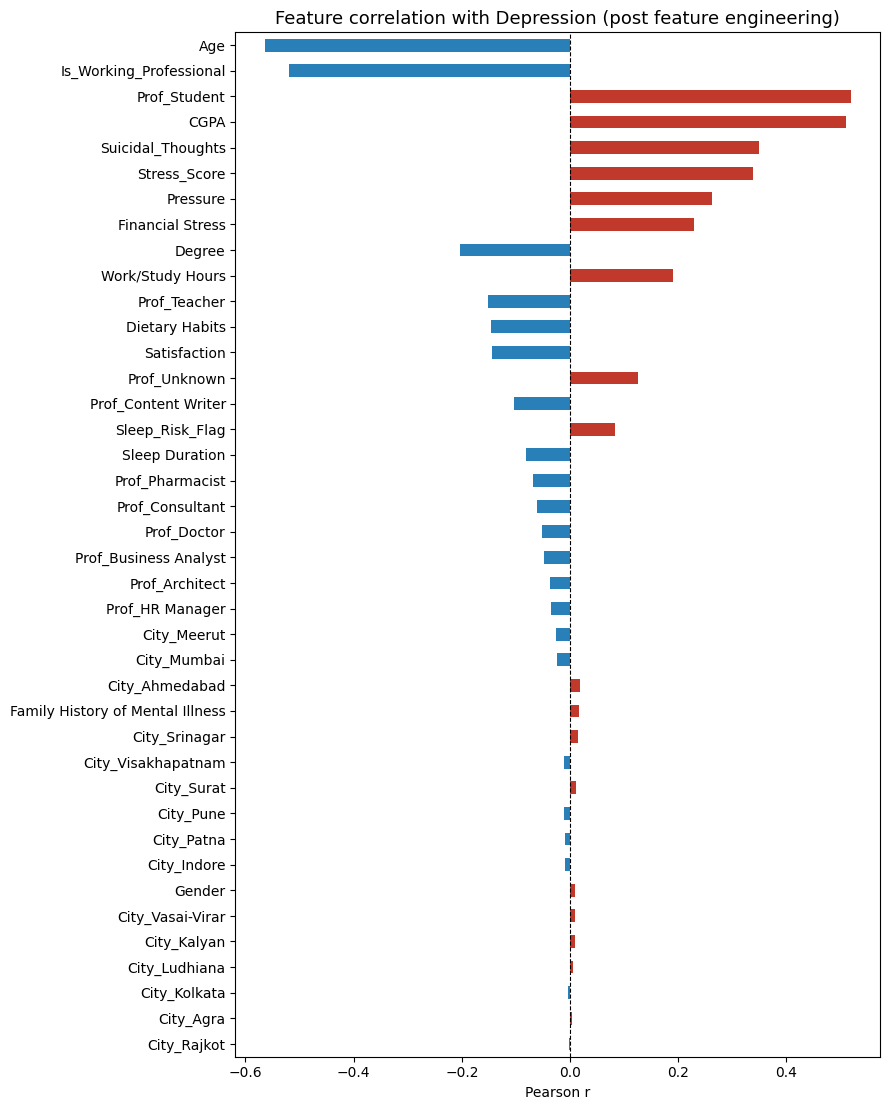

Saved: /content/drive/MyDrive/Data_for_IDA/artifacts/feature_correlation.png


In [37]:
# Correlation with target — quick visual
TARGET   = "Depression"
num_cols = [c for c in train.select_dtypes(include="number").columns if c != TARGET]

corr = (
    train[num_cols + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(9, max(6, len(corr) * 0.28)))
colors = ["#c0392b" if v > 0 else "#2980b9" for v in corr]
corr.plot(kind="barh", ax=ax, color=colors, edgecolor="none")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Feature correlation with Depression (post feature engineering)", fontsize=13)
ax.set_xlabel("Pearson r")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "feature_correlation.png", dpi=150)
plt.show()
print("Saved:", ARTIFACT_DIR / "feature_correlation.png")

---
## 3.7 Save Engineered Datasets

In [38]:
train.to_csv(TRAIN_OUT, index=False)
test.to_csv(TEST_OUT,   index=False)

print(f"Saved  fe_train.csv  ->  {train.shape}")
print(f"Saved  fe_test.csv   ->  {test.shape}")
print("\nAll artifacts in", ARTIFACT_DIR, ":")
for f in sorted(ARTIFACT_DIR.iterdir()):
    print(f"  {f.name}")

Saved  fe_train.csv  ->  (112552, 41)
Saved  fe_test.csv   ->  (28138, 41)

All artifacts in /content/drive/MyDrive/Data_for_IDA/artifacts :
  confusion_matrices.png
  feature_correlation.png
  lr_coefficients.png
  lr_model.pkl
  ohe_categories.pkl
  ordinal_maps.pkl
  rf_feature_importance.png
  rf_model.pkl
  robust_scaler.pkl
  roc_curves.png
  shap_bar.png
  shap_beeswarm.png
  xgb_best.pkl
  xgb_default.pkl
  xgb_feature_importance.png
